# Классификация пола рассказчика аудиокниги

Взял 16 аудиокниг/глав по ~45 минут, из которых 8 с мужским голосом и 8 с женским голосом, и разбил на клипы 2,5 сек.

## Импорты + настройки

In [350]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.manifold import TSNE
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm


CFG = {
    "metadata": "data/gender_dataset/metadata.csv",
    "features": "data/gender_dataset/features_mel",
    "tb_root": "tbs",
    "run_name": "lstm",

    "sr": 16000,
    "clip_sec": 2.5,
    "n_mels": 64,
    "n_fft": 512,
    "hop_length": 160,
    "win_length": 400,
    "fmin": 80,
    "fmax": 8000,
    "eps": 1e-7,

    "random_state": 1234,
    "val_size": 0.25,
    "test_size": 0.25 ,

    "batch_size": 64,
    "epochs": 10,
    "lr": 1e-3,

    "lstm_hidden": 128,
    "lstm_layers": 1,
    "dropout": 0.2,
    "patience": 3,
    "emb_dim": 128,
}

FEATURES_DIR = Path(CFG["features"])
Path(CFG["features"]).mkdir(parents=True, exist_ok=True)

TB_DIR = Path(CFG["tb_root"]) / CFG["run_name"]
TB_DIR.mkdir(parents=True, exist_ok=True)

METADATA_PATH = Path(CFG["metadata"]).resolve()
DATASET_ROOT = METADATA_PATH.parent
df = pd.read_csv(METADATA_PATH)
df["clip_path"] = df["clip_path"].apply(lambda p: str((DATASET_ROOT / p).resolve()))

device = torch.device("mps" if torch.mps.is_available() else "cpu")

## EDA

In [351]:
print("rows:", len(df))

labels = df["gender_str"].value_counts()
print(labels)

print("books:", df["book_id"].nunique())

rows: 10746
gender_str
male      5375
female    5371
Name: count, dtype: int64
books: 16


Классы практически сбалансированны. Небольшая разница в окнах из-за длительности "мужских" и "женских" книг.

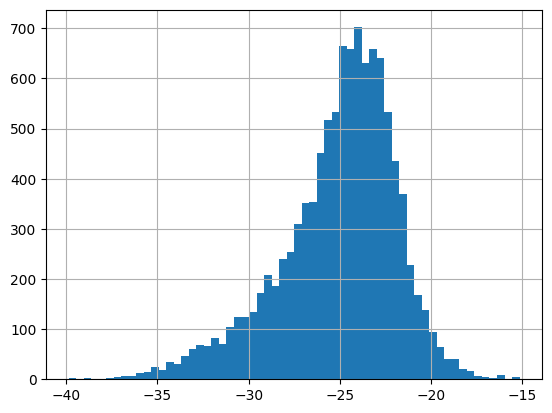

In [384]:
if "rms_dbfs" in df.columns:
    plt.figure()
    df["rms_dbfs"].hist(bins=60)
    plt.show()

При нарезке аудиокниг отфильтровал тихие фрагменты, чтобы в датасете были информативные окна. Для этого фильтровал по громкости.

## Mel признаки и кэширование

In [353]:
for _, r in tqdm(df.iterrows()):
    y, _ = librosa.load(r["clip_path"], sr=CFG["sr"], mono=True)

    target_len = int(CFG["sr"] * CFG["clip_sec"])
    if len(y) > target_len:
        y = y[:target_len]
    else:
        y = np.pad(y, (0, target_len - len(y)))

    S = librosa.feature.melspectrogram(
        y=y, sr=CFG["sr"],
        n_mels=CFG["n_mels"], n_fft=CFG["n_fft"],
        hop_length=CFG["hop_length"], win_length=CFG["win_length"],
        fmin=CFG["fmin"], fmax=CFG["fmax"], power=2.0
    )
    X = np.log(S + CFG["eps"]).T.astype(np.float32)

    out_path = FEATURES_DIR / r["book_id"] / (Path(r["clip_path"]).stem + ".npy")
    out_path.parent.mkdir(parents=True, exist_ok=True)
    np.save(out_path, X)

10746it [00:17, 623.73it/s]


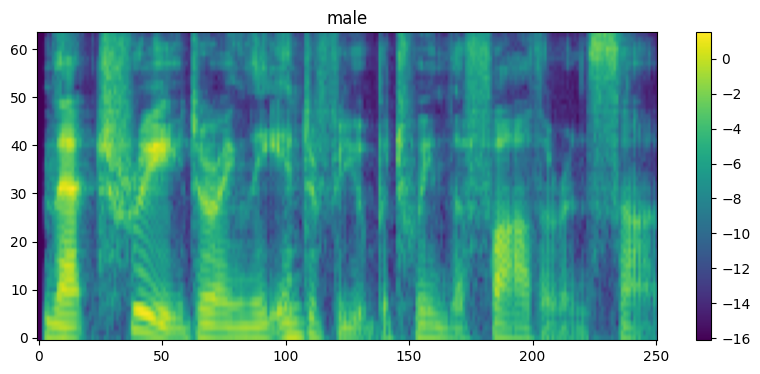

In [354]:
row_m = df[df["gender_str"] == "male"].sample(1, random_state=CFG["random_state"]).iloc[0]
y, _ = librosa.load(row_m["clip_path"], sr=CFG["sr"], mono=True)
S = librosa.feature.melspectrogram(
    y=y, sr=CFG["sr"],
    n_mels=CFG["n_mels"], n_fft=CFG["n_fft"],
    hop_length=CFG["hop_length"], win_length=CFG["win_length"],
    fmin=CFG["fmin"], fmax=CFG["fmax"], power=2.0
)
S = np.log(S + CFG["eps"])

plt.figure(figsize=(10, 4))
plt.imshow(S, aspect="auto", origin="lower")
plt.title("male")
plt.colorbar()
plt.show()

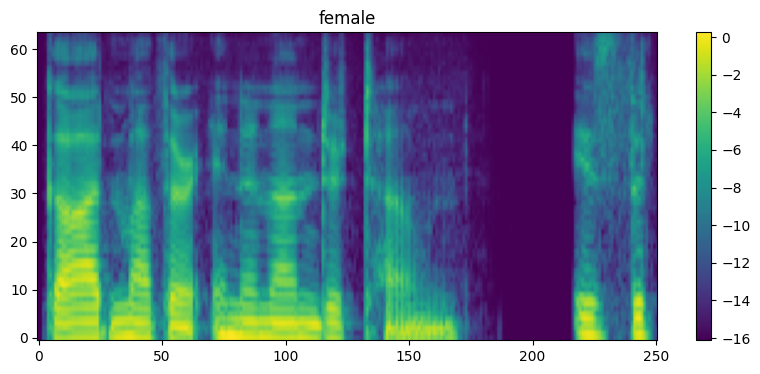

In [355]:
row_f = df[df["gender_str"] == "female"].sample(1, random_state=CFG["random_state"]).iloc[0]
y, _ = librosa.load(row_f["clip_path"], sr=CFG["sr"], mono=True)
S = librosa.feature.melspectrogram(
    y=y, sr=CFG["sr"],
    n_mels=CFG["n_mels"], n_fft=CFG["n_fft"],
    hop_length=CFG["hop_length"], win_length=CFG["win_length"],
    fmin=CFG["fmin"], fmax=CFG["fmax"], power=2.0
)
S = np.log(S + CFG["eps"])

plt.figure(figsize=(10, 4))
plt.imshow(S, aspect="auto", origin="lower")
plt.title("female")
plt.colorbar()
plt.show()

Заметны паузы, основная речь на низких частотах. Признаки корректные и информативные.

## Препроцессинг

Split train/val/test:

In [374]:
def make_book_split(df):
    rng = random.Random(CFG["random_state"])

    books_m = df[df["gender_str"] == "male"]["book_id"].unique().tolist()
    books_f = df[df["gender_str"] == "female"]["book_id"].unique().tolist()
    rng.shuffle(books_m)
    rng.shuffle(books_f)

    n_val_m = max(1, int(len(books_m) * CFG["val_size"]))
    n_test_m = max(1, int(len(books_m) * CFG["test_size"]))
    n_val_f = max(1, int(len(books_f) * CFG["val_size"]))
    n_test_f = max(1, int(len(books_f) * CFG["test_size"]))

    val_books = books_m[:n_val_m] + books_f[:n_val_f]
    test_books = books_m[n_val_m:n_val_m+n_test_m] + books_f[n_val_f:n_val_f+n_test_f]
    train_books = books_m[n_val_m+n_test_m:] + books_f[n_val_f+n_test_f:]

    df_train = df[df["book_id"].isin(train_books)].reset_index(drop=True)
    df_val = df[df["book_id"].isin(val_books)].reset_index(drop=True)
    df_test = df[df["book_id"].isin(test_books)].reset_index(drop=True)

    return df_train, df_val, df_test, {"train": train_books, "val": val_books, "test": test_books}


df_train, df_val, df_test, split_info = make_book_split(df)

print("books:", {k: len(v) for k, v in split_info.items()})
print("clips:", len(df_train), len(df_val), len(df_test))

books: {'train': 8, 'val': 4, 'test': 4}
clips: 5362 2697 2687


Разделил по книгам, чтобы окна одной и той же книги не попадали одновременно в train/val/test.

In [375]:
class GenderDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.features_dir = Path(CFG["features"])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]

        feat_path = self.features_dir / r["book_id"] / (Path(r["clip_path"]).stem + ".npy")
        x = np.load(str(feat_path))

        y = int(r["gender"])            

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(y, dtype=torch.long)
        return x, y

train_ds = GenderDataset(df_train)
val_ds = GenderDataset(df_val)
test_ds = GenderDataset(df_test)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False)
test_loader = DataLoader(test_ds, batch_size=CFG["batch_size"], shuffle=False)

## Модель

In [376]:
class LSTM(nn.Module):
    def __init__(self, n_mels, hidden, layers, emb_dim, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            n_mels,
            hidden,
            num_layers=layers,
            batch_first=True)
        
        self.emb = nn.Linear(hidden, emb_dim)
        self.drop = nn.Dropout(dropout)
        self.cls = nn.Linear(emb_dim, 2)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h = h[-1]
        emb = torch.relu(self.emb(h))
        emb = self.drop(emb)
        logits = self.cls(emb)
        return logits, emb

model = LSTM(
    n_mels=CFG["n_mels"],
    hidden=CFG["lstm_hidden"],
    layers=CFG["lstm_layers"],
    emb_dim=CFG["emb_dim"],
    dropout=CFG["dropout"],
).to(device)

Loss + tb:

In [377]:
loss_foo = nn.CrossEntropyLoss()
writer = SummaryWriter(log_dir=str(TB_DIR))

Обучение:

In [378]:
@torch.no_grad()
def evaluate(model, loader, loss_foo, device):
    model.eval()

    total_loss = 0.0
    y_true_all = []
    y_pred_all = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits, _ = model(x)
        loss = loss_foo(logits, y)
        total_loss += loss.item()

        pred = logits.argmax(dim=1)
        y_true_all.append(y.cpu().numpy())
        y_pred_all.append(pred.cpu().numpy())

    avg_loss = total_loss / len(loader)

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)

    acc = (y_true == y_pred).mean()
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    return {"loss": avg_loss, "acc": acc, "f1": f1}


def fit(model, train_loader, val_loader, loss_foo, device, writer):
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"])

    best_f1 = -1.0
    best_state = None
    no_improve = 0

    for epoch in range(1, CFG["epochs"] + 1):
        model.train()
        total_loss = 0.0
        total_acc = 0.0

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            logits, _ = model(x)
            loss = loss_foo(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_acc += (logits.argmax(dim=1) == y).float().mean().item()

        train_loss = total_loss / len(train_loader)
        train_acc = total_acc / len(train_loader)

        val_m = evaluate(model, val_loader, loss_foo, device)

        writer.add_scalar("loss/train", train_loss, epoch)
        writer.add_scalar("acc/train", train_acc, epoch)
        writer.add_scalar("loss/val", val_m["loss"], epoch)
        writer.add_scalar("acc/val", val_m["acc"], epoch)
        writer.add_scalar("f1/val", val_m["f1"], epoch)

        print(f"[lstm] epoch {epoch:02d} | " f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} | "
              f"val_loss={val_m['loss']:.4f} val_acc={val_m['acc']:.3f} val_f1={val_m['f1']:.3f}")

        if val_m["f1"] > best_f1 + 1e-4:
            best_f1 = val_m["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= CFG["patience"]:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    print(f"done: best_val_f1={best_f1:.3f}")
    return {"best_val_f1": best_f1}


fit_info = fit(
    model,
    train_loader,
    val_loader,
    loss_foo,
    device,
    writer,
)
writer.close()

[lstm] epoch 01 | train_loss=0.4265 train_acc=0.797 | val_loss=0.4129 val_acc=0.791 val_f1=0.787
[lstm] epoch 02 | train_loss=0.1078 train_acc=0.960 | val_loss=0.2048 val_acc=0.918 val_f1=0.918
[lstm] epoch 03 | train_loss=0.0625 train_acc=0.978 | val_loss=0.2339 val_acc=0.919 val_f1=0.919
[lstm] epoch 04 | train_loss=0.0390 train_acc=0.985 | val_loss=0.2274 val_acc=0.920 val_f1=0.919
[lstm] epoch 05 | train_loss=0.0540 train_acc=0.979 | val_loss=0.1927 val_acc=0.928 val_f1=0.928
[lstm] epoch 06 | train_loss=0.0237 train_acc=0.991 | val_loss=0.1368 val_acc=0.949 val_f1=0.949
[lstm] epoch 07 | train_loss=0.0400 train_acc=0.984 | val_loss=0.1596 val_acc=0.942 val_f1=0.942
[lstm] epoch 08 | train_loss=0.0251 train_acc=0.991 | val_loss=0.5692 val_acc=0.815 val_f1=0.808
[lstm] epoch 09 | train_loss=0.0260 train_acc=0.989 | val_loss=0.1807 val_acc=0.943 val_f1=0.942
done: best_val_f1=0.949


In [379]:
@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    y_true_all, y_pred_all = [], []

    for x, y in loader:
        x = x.to(device)
        logits, _ = model(x)
        pred = logits.argmax(dim=1).cpu().numpy()

        y_true_all.append(y.numpy())
        y_pred_all.append(pred)

    return np.concatenate(y_true_all), np.concatenate(y_pred_all)

y_true, y_pred = predict(model, test_loader, device)
print("Classification report:")
print(classification_report(y_true, y_pred, digits=3))

print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

Classification report:
              precision    recall  f1-score   support

           0      0.938     0.889     0.913      1344
           1      0.895     0.941     0.917      1343

    accuracy                          0.915      2687
   macro avg      0.916     0.915     0.915      2687
weighted avg      0.916     0.915     0.915      2687

Confusion matrix:
[[1195  149]
 [  79 1264]]


Модель распознает женский голос и иногда путает мужской с женским. Возможно, из-за англоязычного акцента.

## Эмбеддинги и t-SNE

In [380]:
@torch.no_grad()
def extract_embeddings(model, df_sub, batch_size):
    model.eval()

    ds = GenderDataset(df_sub)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    embs = []
    ys = []
    for xb, yb in loader:
        xb = xb.to(device)
        logits, emb = model(xb)       
        embs.append(emb.cpu().numpy())
        ys.append(yb.numpy())

    embs = np.concatenate(embs, axis=0)
    ys = np.concatenate(ys, axis=0)
    
    return embs, ys

In [381]:
n_vis = min(4000, len(df)) 
df_vis = df.sample(n=n_vis, random_state=CFG["random_state"]).reset_index(drop=True)

embs, ys = extract_embeddings(model, df_vis, batch_size=256)
embs_std = StandardScaler().fit_transform(embs)

tsne = TSNE(
    n_components=2,
    perplexity=40,
    init="pca",
    learning_rate="auto",
    random_state=CFG["random_state"]
)

z = tsne.fit_transform(embs_std)

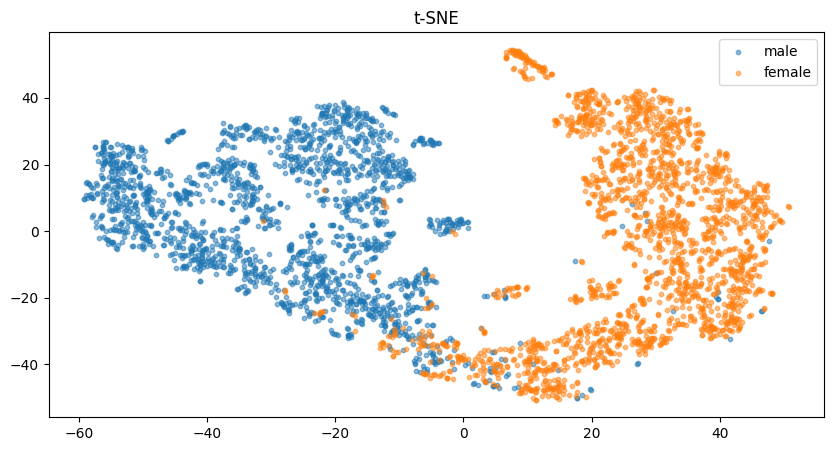

In [382]:
plt.figure(figsize=(10, 5))

mask_m = (ys == 0)
mask_f = (ys == 1)

plt.scatter(z[mask_m, 0], z[mask_m, 1], s=10, alpha=0.5, label="male")
plt.scatter(z[mask_f, 0], z[mask_f, 1], s=10, alpha=0.5, label="female")
plt.title("t-SNE")
plt.legend()
plt.show()

t-SNE показывает хорошее разделение двух классов, есть небольшое смешивание.

## Выводы

Обучил lstm-классификатор на мелспектрограммах. Метрики хорошие, модель различает мужской и женский голос на новых книгах.
По tensorboard видно, что train loss стабильно падает, early stopping помогает не уходить в переобучение.